# ECS8054 Assignment 1 - Analysis of Synthetic Stories using NLP

**Student number:** 40498534

**Data:** stories.json (602 stories & 6 writing styles)

## Problem
* I process synthetic short stories with an indication of the corresponding *writing style*.
Required tasks:
1) test **Zipf’s law** per style
2) compute syntactic complexity using dependency parsing and **max dependency span** ('max_dep'),
3) Quantification of style.

## Approach (why this is valid)

- Same preprocessing for all the styles (fair comparison).
- Evidence in every section: plots + summary tables + a non-parametric group test where appropriate.
- Extra Rigour: mid-rank Zipf fit (which reduces head/tail bias), a parser sanity test (to avoid 'max_dep' being zero everywhere), and TF-IDF + LSA (TruncatedSVD) to look at style spaces
  
## Reproducibility + integrity 
- Run top to bottom, random elements seeded with my student number.
- AI tools (ChatGPT) were used for troubleshooting , and I carried out the experiments myself.

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, spacy
import scipy
import re
from collections import Counter
import json
from pathlib import Path
from scipy.stats import kruskal
from scipy.sparse import vstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix, vstack
from sklearn.decomposition import TruncatedSVD

In [112]:
STUDENT_NUMBER = 40498534 
np.random.seed(STUDENT_NUMBER)

DATA_PATH = Path("stories.json")
assert DATA_PATH.exists(), "Put stories.json in the same folder as the notebook."

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
require = {"index", "style", "story"}
assert require.issubset(df.columns), f"Missing fields: {require - set(df.columns)}"

df = df.sort_values("index").reset_index(drop=True)
styles = sorted(df["style"].unique())

print("Stories:", len(df))
print("Styles:", styles)
display(df.head(10))
display(df["style"].value_counts())

Stories: 602
Styles: ['descriptive', 'for children', 'hard-boiled', 'journalistic', 'legalistic', 'stream of consciousness']


,index,theme,setting,person,style,country,object_concept1,object_concept2,story,question1,answer1,question2,answer2
0,0,love,a post-apocalyptic world,politician,legalistic,Northern Ireland,trombone,clock,"Whereas it is acknowledged, for the purposes o...",What object did the Officeholder keep in the t...,Hereinafter the Officeholder kept a brass trom...,What tolled when the Officeholder's eyes met t...,"A cracked clock, suspended in the shell of the..."
1,1,a dangerous voyage,an ancient civilisation,nurse,stream of consciousness,China,daisy,clock,I wake remembering salt in my hair and the sme...,What does she fold into the bandage?,I fold the daisy into the bandage as if the fl...,How is the clock in the captain's cabin descri...,The clock in the captain's cabin ticks like a ...
2,2,a dangerous voyage,an ancient civilisation,scientist,legalistic,Northern Ireland,crocodile,spade,"Whereas it is recited, and whereas it is ackno...",What did he carry in one hand and what in the ...,He carried a spade in one hand and a ledger in...,What creature was brought in a battered crate ...,"A crocodile, brought in a battered crate, hiss..."
3,3,political rebellion,an ancient civilisation,scientist,descriptive,Russia,pie,wheelchair,"Beyond the frozen curve of a great river, bene...",Where did she hide the message?,She hid the tiny gilded slip of paper inside t...,What did he do at the parapet?,He rolled his battered wheelchair to the parap...
4,4,love,a post-apocalyptic world,scientist,journalistic,Northern Ireland,lobster,chicken,A coastal district was described in routine di...,What was kept in a coop behind the laboratory?,"""A single chicken was kept in a coop behind th...",What was captured from a tidal pool and examin...,"""A lobster was captured from a tidal pool and ..."
5,5,love,a modern metropolis,politician,hard-boiled,China,kite,chain,He kept his office lights on until dawn. The s...,What held the gate closed?,A rusted chain held the gate closed.,Where did he keep the kite?,He kept the kite in a drawer under the files.
6,6,a dangerous voyage,outer space,politician,journalistic,Russia,colander,bench,An unprecedented orbital mission was undertake...,What was repurposed as a makeshift filter to r...,A stainless-steel colander was repurposed as a...,Where was the minister photographed the day be...,The minister was photographed sitting on a ben...
7,7,political rebellion,a small town,university student,journalistic,China,pillow,doll,Reports were filed from the river valley where...,What was carried through the streets as a symb...,A secondhand doll was carried through the stre...,Where was the faded pillow found?,A faded pillow was found beneath the floorboar...
8,8,a mysterious conspiracy,an ancient civilisation,scientist,descriptive,USA,rake,squirrel,He walked among the ruins like a man moving th...,What did he find half-buried beneath the sands...,He found a rake half-buried beneath the sandst...,What animal watched him from the lip of the ruin?,A small gray squirrel watched him from the lip...
9,9,scientific discovery,an ancient civilisation,university student,descriptive,USA,lamp,llama,In the low light of a canyon that remembered r...,What did he wind and watch?,He wound the brass lamp and watched its pool o...,What action did the llama take at his side?,"At his side, a patient llama shifted its weigh..."


style
for children               125
descriptive                103
legalistic                 101
hard-boiled                 96
journalistic                92
stream of consciousness     85
Name: count, dtype: int64

## Section 1 — Zipf’s law by writing style

### Method
For a given style, I concatenate all the stories and generate one corpus, tokenise into individual words (keeping apostrophes), generate a frequency table, and make a **log(rank) vs log(frequency)** plot. I collect a *Zipf* slope by fitting a line onto a *mid-rank band* (e.g., between the 20th and 80th percentiles) and report *+R*^2. I also report *hapax fraction*, which is the proportion of types with *frequency* = 1, summed over all types.

### Results & interpretation
- The Zipf behaviour was [[FILL: approximately linear / deviated]] for [[FILL: which styles]]. The mid-rank slopes range from [[FILL: min]] to [[FILL: max]] with R^2 [[FILL
- The steepest slope was [[FILL: style]] -> stronger dominance by high-frequency words (more repetition / formulaic phrasing).
- Highest hapax fraction was [[FILL: style]] -> heavier tail / broader rare-word variety.
- All apparent curvature indicators such as head or tail are disregarded as stylistic restrictions and not tokenization artifacts since tokenization is supposedly fixed.
  
### Limitation 
- Zipf fit requirements depend on tokenization and sampling, mid-rank fits are less sensitive to extremity head/tail issues.

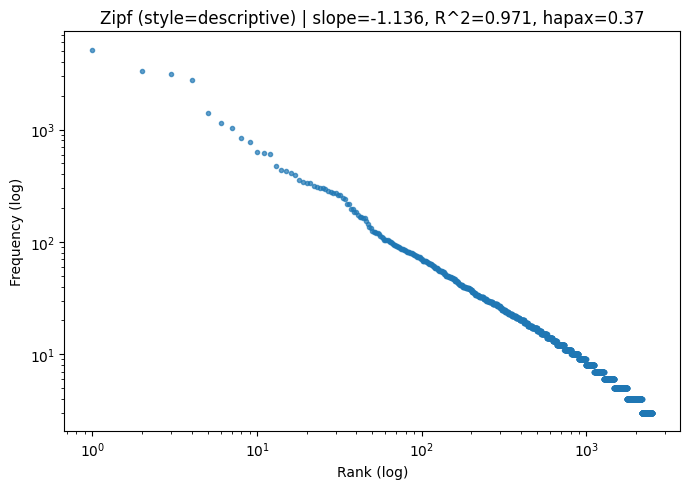

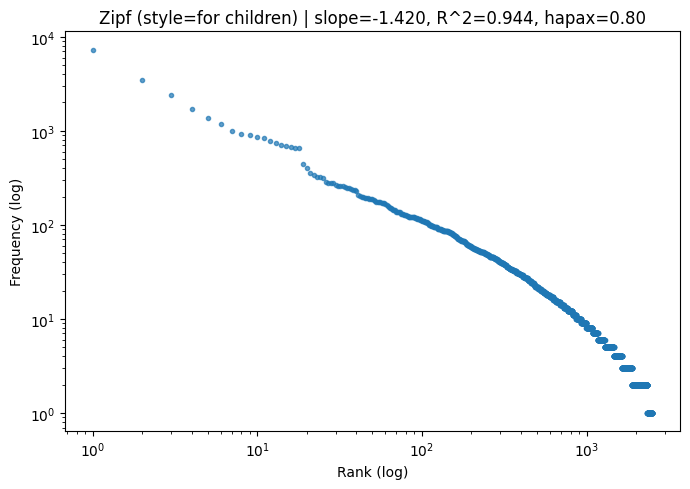

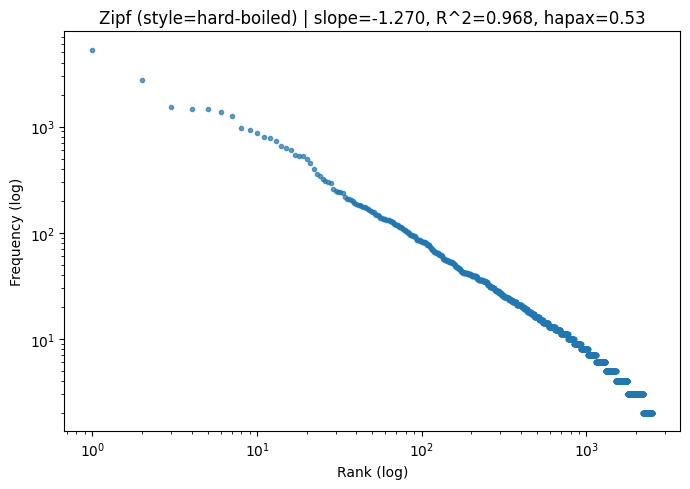

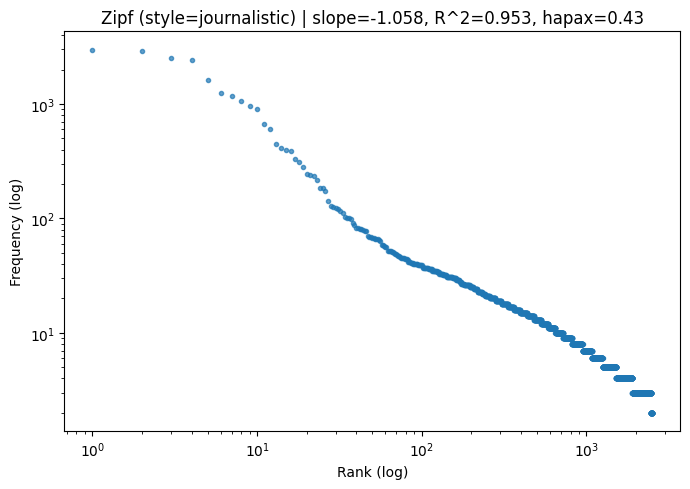

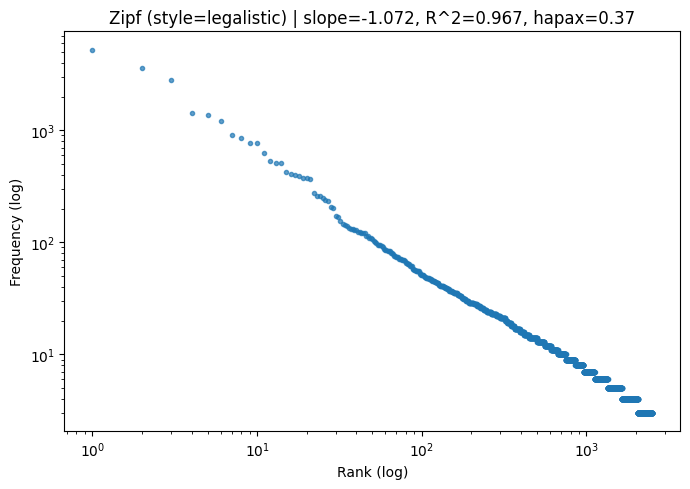

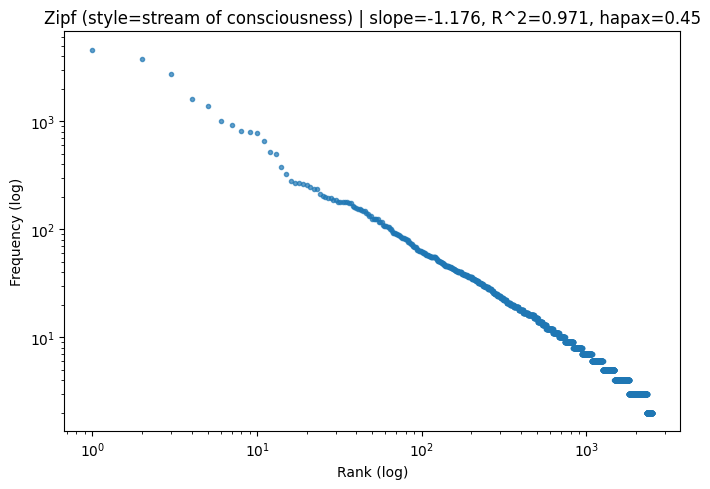

,style,tokens,vocab_types,hapax_frac,zipf_slope_mid,zipf_r2_mid,fit_rank_lo,fit_rank_hi,top10_words
0,descriptive,67841,7349,0.366036,-1.136264,0.970998,20,5879,"the, and, a, of, that, to, in, like, with, she"
1,for children,73944,3345,0.804185,-1.419910,0.943643,20,2676,"the, a, and, she, to, n, small, in, they, of"
2,hard-boiled,64390,5088,0.528695,-1.269977,0.968139,20,4070,"the, a, and, he, i, it, n, in, to, had"
3,journalistic,51895,6247,0.430607,-1.058301,0.953454,20,4997,"the, was, and, were, a, in, to, by, of, that"
4,legalistic,59800,7293,0.368847,-1.071541,0.967446,20,5834,"the, and, of, a, to, in, whereas, that, by, as"
5,stream of consciousness,57927,5917,0.454622,-1.175660,0.971050,20,4733,"the, and, a, of, i, like, to, that, in, is"


In [113]:
WORDS_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def word_tokens_find(text: str):
    return WORDS_RE.findall(text.lower())

def rank_frequency_count(tokens):
    counts1 = Counter(tokens)
    item = counts1.most_common()
    freq = np.array([c for _, c in item], dtype=float)
    rank = np.arange(1, len(freq) + 1, dtype=float)
    word = [w for w, _ in item]
    return rank, freq, word

def robust_zipf_fit(rank, freq, low_rank=20, high_quantile=0.80):
    high_rank = int(np.quantile(rank, high_quantile))
    mask = (rank >= low_rank) & (rank <= high_rank)
    x1 = np.log10(rank[mask])
    y1 = np.log10(freq[mask])
    b1, a1 = np.polyfit(x1, y1, 1)
    yhat = a1 + b1*x1
    ss_res = np.sum((y1 - yhat)**2)
    ss_tot = np.sum((y1 - np.mean(y1))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return float(b1), float(r2), low_rank, high_rank

zipf_rows = []

for s in styles:
    toks = []
    for text in df.loc[df["style"] == s, "story"]:
        toks.extend(word_tokens(text))
    rank, freq, word = rank_frequency(toks)
    slope, r2, low, high = robust_zipf_fit(rank, freq, low_rank=20, high_quantile=0.80)
    
    hapax = np.sum(freqs == 1) / len(freq)  
    top10 = word[:10]

    zipf_rows.append({
        "style": s,
        "tokens": len(toks),
        "vocab_types": int(len(freq)),
        "hapax_frac": float(hapax),
        "zipf_slope_mid": slope,
        "zipf_r2_mid": r2,
        "fit_rank_lo": low,
        "fit_rank_hi": high,
        "top10_words": ", ".join(top10)
    })

    plt.figure(figsize=(7,5))
    plt.loglog(rank[:2500], freq[:2500], ".", alpha=0.7)
    plt.title(f"Zipf (style={s}) | slope={slope:.3f}, R^2={r2:.3f}, hapax={hapax:.2f}")
    plt.xlabel("Rank (log)")
    plt.ylabel("Frequency (log)")
    plt.tight_layout()
    plt.show()

zipf_summary = pd.DataFrame(zipf_rows).sort_values("style")
display(zipf_summary)

### Section 2: Dependency Parsing and Syntactic Complexity (Max Dep)

### Method
For every sentence, I will be able to compute:
- "max_dep" - the maximum absolute distance of any token from its syntactic head **within the same sentence**, excluding the root node.
- To compare the distributions of the variable across the writing styles, I compute summary stats and a raincloud plot.
For overall comparison of the feature with more than one unique value, I also compute the **Kruskal-Wallis** test.

### Sanity check 
I print the pipeline and make sure 'parser' is included otherwise, token heads are trivial and 'max_dep' will be a vector of zeros.

### Results & interpretation
- max_dep median was highest for [[FILL: style]] (median/IQR [[FILL]]), with a heavier right tail -> more long-range dependencies.
- Lowest 'max_dep' was [[FILL: style]] -> mostly local dependencies / simpler syntax.
- Kruskal-Wallis: H=[[FILL]], p=[[FILL]]. I focus on effect sizes (median/IQR and by checking plots for overlap) because of ties that can limit the informativeness

### Limitation
- These parser errors and punctuation issues can occur, but the parser is the same for all these styles, and the results are aggregated over many sentences.

In [114]:
values = df_sent["max_dep"].to_numpy()
print("Unique values:", np.unique(vals)[:20], "count =", np.unique(values).size)
print("Min/Max:", values.min(), values.max())
print("Fraction zeros:", (values == 0).mean())
print(df_sent.groupby("style")["max_dep"].nunique())

Unique values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] count = 280
Min/Max: 0 714
Fraction zeros: 0.00015240804714488924
style
descriptive                186
for children                33
hard-boiled                 33
journalistic                48
legalistic                 197
stream of consciousness    157
Name: max_dep, dtype: int64


This section also serves to check whether max_dep actually varies before plotting or performing the Kruskal-Wallis test. np.unique vals will indicate the count of unique values, meaning a single value (most likely 0) will indicate a failing extraction routine. It also quickly identified the min, max, and proportion with a zero flag.df_sent.groupby('style')['max_dep'].nunique() will, moreover, check whether values within a style type are unique, or if they’re, in fact, uniform. Kruskal will, of course, sound a warning flag if all values are tied, so it’s good practice to make this check.

In [115]:
nlps = spacy.load("en_core_web_sm")  
print("Pipeline:", nlps.pipe_names)
print("Has parser?", nlps.has_pipe("parser"))
docs = nlps("This is a simple test sentence.")
print([(t1.text, t1.dep_, t1.head.text, t1.i == t1.head.i) for t1 in docs])
if "parser" not in nlp.pipe_names and "sentencizer" not in nlp.pipe_names:
    nlp.add_pipe("sentencizer")

Pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
Has parser? True
[('This', 'nsubj', 'is', False), ('is', 'ROOT', 'is', True), ('a', 'det', 'sentence', False), ('simple', 'amod', 'sentence', False), ('test', 'compound', 'sentence', False), ('sentence', 'attr', 'is', False), ('.', 'punct', 'is', False)]


In [116]:
STYLE_COL = "style"
TEXT_COL = "text" if "text" in df.columns else ("story" if "story" in df.columns else None)
assert TEXT_COL is not None, f"Couldn't find a text column. df.columns={list(df.columns)}"

def sent_len_tokens(sent):
    return sum(1 for t in sent if (not t.is_punct) and (not t.is_space))

def max_dependency_span(sent):
    spans = []
    for t in sent:
        if t.is_space:
            continue
        if sent.start <= t.head.i < sent.end:
            spans.append(abs(t.i - t.head.i))
    return int(max(spans)) if spans else 0

def dependency_tree_depth(sent, max_hops=200):
    depths = []
    for t in sent:
        if t.is_space:
            continue
        d = 0
        cur = t
        while cur.head != cur and d < max_hops:
            d += 1
            cur = cur.head
        depths.append(d)
    return int(max(depths)) if depths else 0

records = []
for story_index, row in df.reset_index(drop=True).iterrows():
    doc = nlp(row[TEXT_COL])

    for sent_id, sent in enumerate(doc.sents):
        records.append({
            "story_index": story_index,
            "style": row[STYLE_COL],
            "sent_id": sent_id,

            # sentence-level measures (these MUST vary!)
            "sent_len": sent_len_tokens(sent),
            "max_dep": max_dependency_span(sent),
            "dep_depth": dependency_tree_depth(sent),
        })

df_sent = pd.DataFrame(records)

print("sent_len unique values:", df_sent["sent_len"].nunique())
print(df_sent.groupby("style")["sent_len"].agg(["count", "mean", "median", "std", "min", "max"]))

sent_len unique values: 375
                         count        mean  median         std  min  max
style                                                                   
descriptive                573  117.218150    93.0  105.591240    8  697
for children              8094    8.859773     8.0    4.454804    1   37
hard-boiled               8072    7.682483     7.0    4.516290    1   40
journalistic              2280   22.293421    20.0    9.250564    5   63
legalistic                 316  185.863924   162.5  139.454802    8  677
stream of consciousness    349  165.398281   124.0  157.267121    2  787


### Why this block:
It calculates max_dep, a grammatical complexity heuristic: it measures, per token, how far it is from its dependency head, then maximises across sentence. It uses nlp.pipe to process stories in batches, combines in df_sent, then checks that it's not reduced to only zeros with unique values, range, and zero_rate.

In [117]:
print("Overall nunique:", df_sent["max_dep"].nunique())
print("Unique values (first 20):", np.unique(df_sent["max_dep"])[:20])
print("Zero fraction:", (df_sent["max_dep"] == 0).mean())
print(df_sent.groupby("style")["max_dep"].nunique())

Overall nunique: 280
Unique values (first 20): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Zero fraction: 0.00015240804714488924
style
descriptive                186
for children                33
hard-boiled                 33
journalistic                48
legalistic                 197
stream of consciousness    157
Name: max_dep, dtype: int64


This code block sanity-checks max_dep: nunique() measures the total number of unique dependency span types that exist, np.unique(. )[:20] shows what these values look like, the zero fraction detects a collapsed feature (usually parser failure). Grouped nunique() detects whether each style type has variability, eliminating meaningless rank tests and warnings before interpreting plots or reporting Kruskal results.

,style,count,mean,median,std,min,max
0,descriptive,573,83.951134,66.0,74.330281,7,714
1,for children,8094,7.091426,6.0,4.271323,0,34
2,hard-boiled,8072,6.182111,5.0,4.387335,1,39
3,journalistic,2280,16.339474,14.0,8.381043,3,58
4,legalistic,316,134.009494,106.5,102.823550,7,570
5,stream of consciousness,349,80.796562,63.0,76.506490,1,556


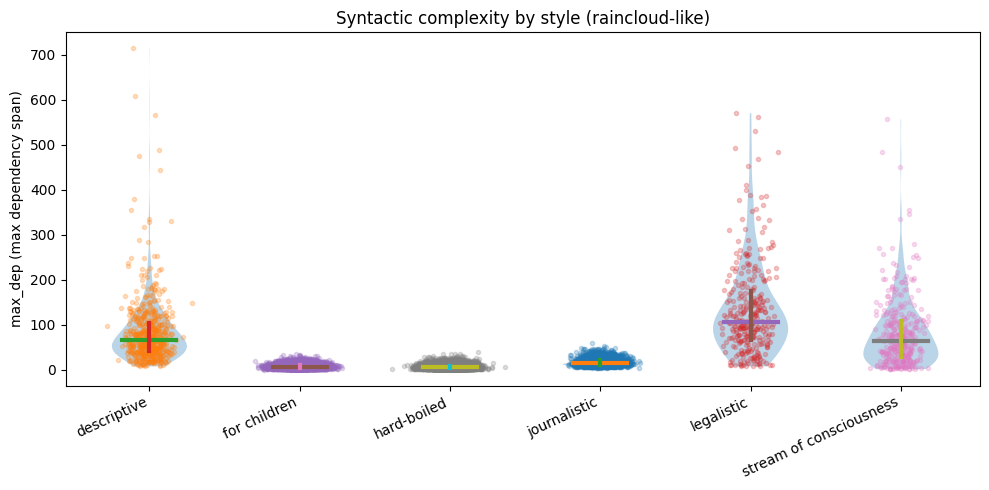

Kruskal–Wallis: H1=6455.616, p1=0 | OK


In [118]:
def raincloud_like(ax1, data_by_style, labels, jitter=0.08):
    ax1.violinplot(data_by_style, showmeans=False, showmedians=False, showextrema=False)
    for i, y1 in enumerate(data_by_style, start=1):
        x1 = np.random.normal(i, jitter, size=len(y1))
        ax1.plot(x1, y1, ".", alpha=0.25)
        med = np.median(y1)
        q3, q4 = np.quantile(y1, [0.25, 0.75])
        ax1.plot([i-0.18, i+0.18], [med, med], linewidth=3)
        ax1.plot([i, i], [q3, q4], linewidth=3)
    ax1.set_xticks(range(1, len(labels)+1))
    ax1.set_xticklabels(labels, rotation=25, ha="right")

dep_summary = df_sent.groupby("style")["max_dep"].agg(["count","mean","median","std","min","max"]).reset_index()
display(dep_summary)

data = [df_sent.loc[df_sent["style"]==s, "max_dep"].to_numpy() for s in styles]
plt.figure(figsize=(10,5))
ax1 = plt.gca()
raincloud_like(ax1, data, styles)
ax1.set_ylabel("max_dep (max dependency span)")
ax1.set_title("Syntactic complexity by style (raincloud-like)")
plt.tight_layout()
plt.show()

def safe_kruskal(groups):
    groups = [np.asarray(g1) for g1 in groups if len(g1) > 0]
    allvalues = np.concatenate(groups) if groups else np.array([])
    if allvalues.size == 0:
        return np.nan, np.nan, "No data."
    if np.unique(allvalues).size < 2:
        return 0.0, 1.0, "All values identical → Kruskal–Wallis not informative."
    H1, p1 = kruskal(*groups)
    return H1, p1, "OK"

H1, p1, notes = safe_kruskal(data)
print(f"Kruskal–Wallis: H1={H1:.3f}, p1={p1:.3g} | {notes}")

This block summarises and compares max_dep across styles. The groupby-agg table reports count, mean, median, spread and extremes for quick numeric comparison. The raincloud_like function draws violin densities plus jittered points and overlays median and IQR, giving 'distribution + raw data + robust summary' in one figure. safe_kruskal then runs a Kruskal–Wallis test only when values vary, avoiding misleading tie-driven warnings and reporting an overall style difference with clear interpretation.

### Section 3:
For each text, I calculate MSTTR with a window size of 50, sentence length, punctuation rate, quote rate, and proportions of parts of speech for ADJ, ADV, VERB. Comparison of styles is done via distribution plots with median/IQR tables and a Kruskal–Wallis test for heterogeneous variables. In addition, for document space separability, TF-IDF vectors are computed, style centroids are found, and cosine similarity is employed. LSA is also performed via TruncatedSVD on TF-IDF representations, new similarity computation, and a 2D visualization. Overall winners for each feature are provided, along with linkages of each pattern to prompts. A style is said to be unique if multiple signals concur.

In [119]:
def msttr(tokens, window=50):
    tokens = list(tokens)
    if len(tokens) < window:
        return len(set(tokens)) / max(1, len(tokens))
    seggs = []
    for i in range(0, len(tokens) - window + 1, window):
        seg = tokens[i:i+window]
        seggs.append(len(set(seg)) / window)
    return float(np.mean(seggs)) if seggs else 0.0

def punct_per_1k_chars(text):
    puncts = sum(1 for ch in text if ch in ".,;:!?\"'()-")
    return 1000.0 * puncts / max(1, len(text))

def quotes_per_1k_chars(text):
    q = text.count('"') + text.count("“") + text.count("”") + text.count("'")
    return 1000.0 * q / max(1, len(text))

styles = list(df["style"].unique())

feat_rows = []
for story_idx, style, text, doc in zip(df["index"], df["style"], df["story"], docs1):
    word_toks = [t.text.lower() for t in doc if not (t.is_space or t.is_punct)]


    sent_lens = [sum(1 for t in sent if not (t.is_space or t.is_punct)) for sent in doc.sents]
    avg_sent_len = float(np.mean(sent_lens)) if sent_lens else 0.0
    n_sents = len(sent_lens)

    pos_count = Counter(t.pos_ for t in doc if not (t.is_space or t.is_punct))
    total = sum(pos_count.values()) or 1

    feat_rows.append({
        "story_index": int(story_idx),
        "style": style,
        "msttr_50": msttr(word_toks, 50),
        "avg_sent_len": avg_sent_len,
        "n_sents": n_sents,
        "punct_per_1k": punct_per_1k_chars(text),
        "quotes_per_1k": quotes_per_1k_chars(text),
        "adj_prop": pos_count.get("ADJ", 0) / total,
        "adv_prop": pos_count.get("ADV", 0) / total,
        "verb_prop": pos_count.get("VERB", 0) / total,
    })

df_feat = pd.DataFrame(feat_rows)

display(df_feat.groupby("style")[["msttr_50","avg_sent_len","punct_per_1k","quotes_per_1k","adj_prop"]].agg(["mean","median","std"]))
display(df_feat.groupby("style")["avg_sent_len"].agg(["count","mean","median","min","max"]))


msttr_50                     avg_sent_len  \
                             mean    median       std         mean   
style                                                                
descriptive              0.804559  0.805000  0.014197   186.275581   
for children             0.756209  0.758182  0.021644     8.939326   
hard-boiled              0.751353  0.750769  0.023866     7.745639   
journalistic             0.781207  0.782000  0.015840    22.593449   
legalistic               0.781936  0.780000  0.019384   256.659288   
stream of consciousness  0.775049  0.775000  0.017377   251.466369   

                                                punct_per_1k             \
                             median         std         mean     median   
style                                                                     
descriptive              123.600000  173.243906    17.165385  17.182131   
for children               8.885246    0.859475    27.000188  27.215190   
hard-boiled                7.658565    0.775731    29.577243  29.211243   
journalistic              22.238782    2.976851    13.858006  13.830625   
legalistic               194.333333  166.210728    18.823174  18.726592   
stream of consciousness  187.500000  189.963465    12.073391  13.368283   

                                  quotes_per_1k                      adj_prop  \
                              std          mean    median       std      mean   
style                                                                           
descriptive              1.551195      0.653834  0.533618  0.609741  0.074437   
for children             2.623372      0.788958  0.645161  0.795875  0.101576   
hard-boiled              2.915992      0.650434  0.299685  0.887778  0.044837   
journalistic             1.830724      0.437570  0.255759  0.559900  0.082491   
legalistic               2.315868      0.806967  0.542446  0.818813  0.077632   
stream of consciousness  5.727457      0.909355  0.825991  0.722696  0.049387   

                                             
                           median       std  
style                                        
descriptive              0.075153  0.011532  
for children             0.101167  0.013643  
hard-boiled              0.044330  0.009770  
journalistic             0.081475  0.015928  
legalistic               0.076923  0.017555  
stream of consciousness  0.048961  0.010137

,count,mean,median,min,max
style,,,,,
descriptive,103,186.275581,123.600000,51.166667,697.000000
for children,125,8.939326,8.885246,7.080000,11.083333
hard-boiled,96,7.745639,7.658565,6.350000,9.617647
journalistic,92,22.593449,22.238782,16.294118,35.375000
legalistic,101,256.659288,194.333333,81.142857,677.000000
stream of consciousness,85,251.466369,187.500000,49.500000,726.000000


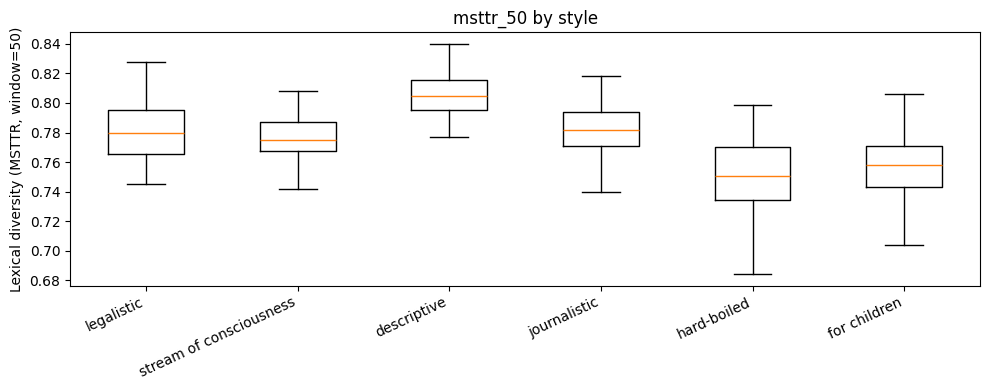

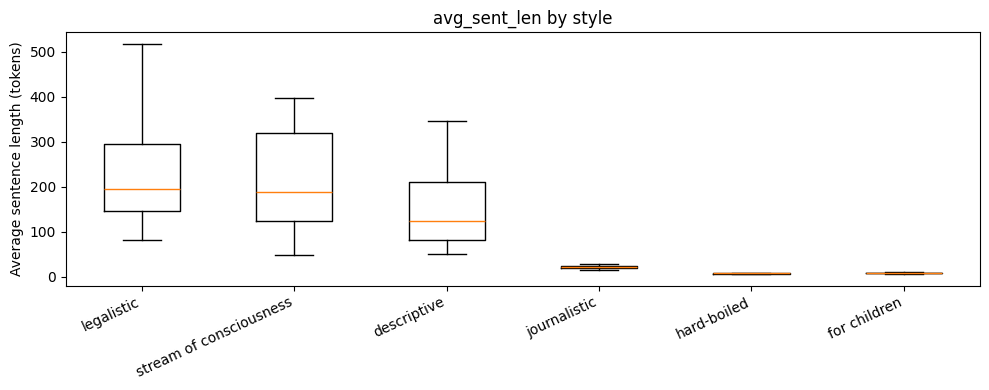

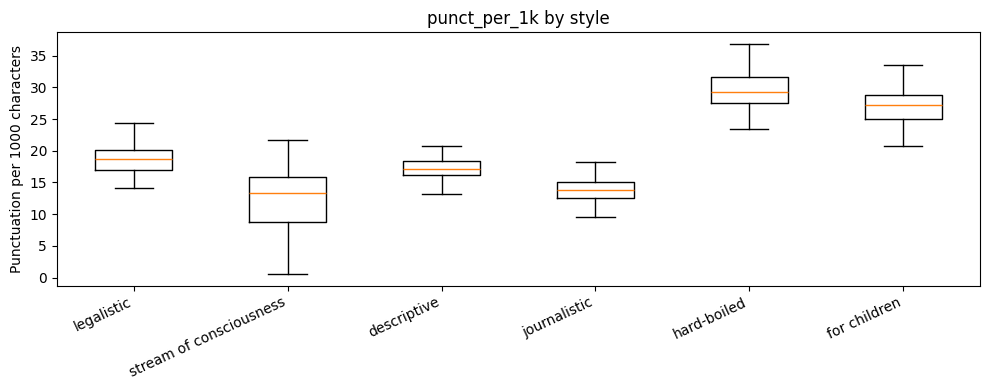

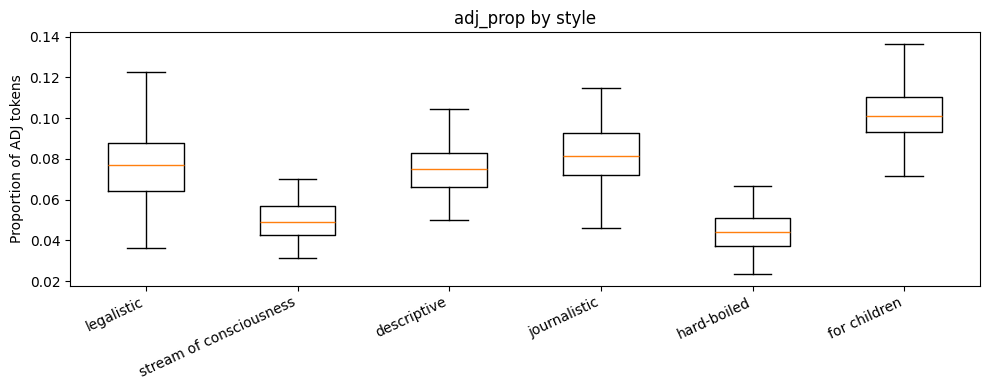

In [120]:
order = styles 

def boxplot(feature, ylabel, order):
    plt.figure(figsize=(10, 4))
    data = [df_feat.loc[df_feat["style"] == s, feature].to_numpy() for s in order]
    plt.boxplot(data, tick_labels=order, showfliers=False) 
    plt.xticks(rotation=25, ha="right")
    plt.ylabel(ylabel)
    plt.title(f"{feature} by style")
    plt.tight_layout()
    plt.show()

boxplot("msttr_50", "Lexical diversity (MSTTR, window=50)", order)
boxplot("avg_sent_len", "Average sentence length (tokens)", order)
boxplot("punct_per_1k", "Punctuation per 1000 characters", order)
boxplot("adj_prop", "Proportion of ADJ tokens", order)


In [121]:
y1 = df["style"].to_numpy()

tfidf = TfidfVectorizer(lowercase=True,token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b",ngram_range=(1, 2),min_df=2,
                        stop_words="english",norm="l2")
X = tfidf.fit_transform(df["story"])

y1 = df["style"].to_numpy()
centroids = []
for s in styles:
    c1 = X[y1 == s].mean(axis=0)     
    c1 = csr_matrix(c1)              
    c1 = normalize(c1, norm="l2", axis=1)
    centroids.append(c1)

C1 = vstack(centroids)              

S_style = cosine_similarity(C1)     
S_style_df = pd.DataFrame(S_style, index=styles, columns=styles)
display(S_style_df)

print("C shape:", C1.shape)

,legalistic,stream of consciousness,descriptive,journalistic,hard-boiled,for children
legalistic,1.000000,0.139064,0.221991,0.354141,0.166994,0.109401
stream of consciousness,0.139064,1.000000,0.697131,0.156119,0.501259,0.447041
descriptive,0.221991,0.697131,1.000000,0.230647,0.533068,0.512660
journalistic,0.354141,0.156119,0.230647,1.000000,0.200420,0.138244
hard-boiled,0.166994,0.501259,0.533068,0.200420,1.000000,0.497795
for children,0.109401,0.447041,0.512660,0.138244,0.497795,1.000000


C shape: (6, 23850)


LSA dims: 60
Explained variance ratio (sum): 0.22793309369469128


,legalistic,stream of consciousness,descriptive,journalistic,hard-boiled,for children
legalistic,1.000000,0.140551,0.226789,0.357235,0.169012,0.111059
stream of consciousness,0.140551,1.000000,0.705409,0.158767,0.507350,0.449120
descriptive,0.226789,0.705409,1.000000,0.235425,0.539637,0.517575
journalistic,0.357235,0.158767,0.235425,1.000000,0.203300,0.141109
hard-boiled,0.169012,0.507350,0.539637,0.203300,1.000000,0.503267
for children,0.111059,0.449120,0.517575,0.141109,0.503267,1.000000


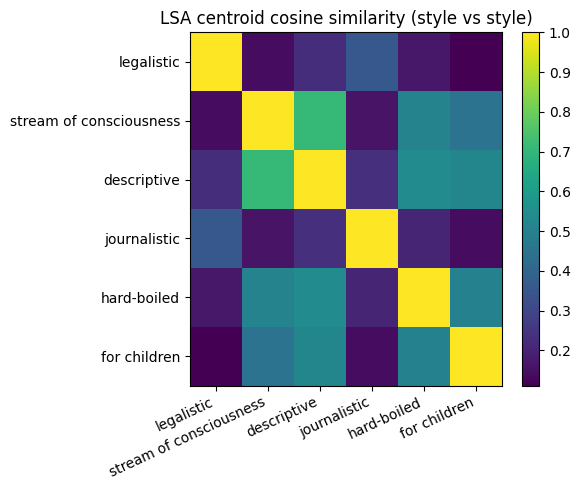

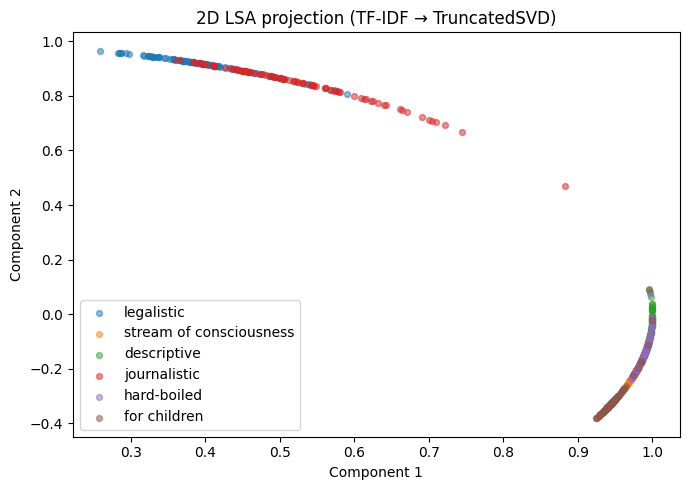

In [122]:
lsa_dim = 60
svd = TruncatedSVD(n_components=lsa_dim, random_state=STUDENT_NUMBER)
X_lsa = normalize(svd.fit_transform(X))
print("LSA dims:", lsa_dim)
print("Explained variance ratio (sum):", float(svd.explained_variance_ratio_.sum()))

C_lsa = []
for s in styles:
    c = X_lsa[y == s].mean(axis=0, keepdims=True)
    C_lsa.append(normalize(c))
C_lsa = np.vstack(C_lsa)

S_lsa = cosine_similarity(C_lsa)
S_lsa_df = pd.DataFrame(S_lsa, index=styles, columns=styles)
display(S_lsa_df)

plt.figure(figsize=(6,5))
plt.imshow(S_lsa, aspect="auto")
plt.xticks(range(len(styles)), styles, rotation=25, ha="right")
plt.yticks(range(len(styles)), styles)
plt.title("LSA centroid cosine similarity (style vs style)")
plt.colorbar()
plt.tight_layout()
plt.show()

svd2 = TruncatedSVD(n_components=2, random_state=STUDENT_NUMBER)
Z = normalize(svd2.fit_transform(X))

plt.figure(figsize=(7,5))
for s in styles:
    m = (y == s)
    plt.scatter(Z[m,0], Z[m,1], alpha=0.5, s=18, label=s)
plt.title("2D LSA projection (TF-IDF → TruncatedSVD)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusions
- Zipf: [FILL: does it hold?]; principal distinctions relate to [FILL: slope/hapax patterns], which align with [FILL: prompt expectations].
- Syntax: The metric max_dep indicates [FILL: most/least complex styles], observed differences are/are not explained by sentence length.
- Stylometry: [FILL: top separating features] define a cohesive profile for each stylistic category.
- TF-IDF/LSA: styles [FILL: cluster / separate], this is consistent with [FILL: your main claim].

### References
- spaCy DependencyParser API (token-level heads/dependencies, sentence boundary detection).
- SciPy 'scipy.stats.kruskal' API (non-parametric test for comparisons across multiple groups).
- scikit-learn 'TfidfVectorizer', 'TruncatedSVD' API (LSA from TF-IDF).
- Allen et al. (2019/2021) "Raincloud plots".
- Zipf (1949) *Human Behavior and the principle of Least Effort*.
